# Lab 06 - 23CSE301
A1: repeat Lab05 (own code, AI-assisted where noted)
A2: unit tests
A3: compare own kNN vs sklearn vs GenAI-generated kNN (accuracy, precision, recall, F1, time)

In [21]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [22]:
# config - change these
RAVDESS_DIR = "RAVDESS"
CREMAD_DIR = "CREMA-D"
EMOTIONS = ["happy", "sad"]
USE_FAKE_DATA = False   # set False once real audio paths above are correct

## Data loading (own code, sped up with threading — GenAI-assisted for the parallel loading part)

In [23]:
def get_mfcc(file_path):
    signal, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return np.mean(mfcc.T, axis=0)

def ravdess_label(filename):
    codes = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
             "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}
    return codes[filename.split("-")[2]]

def cremad_label(filename):
    codes = {"ANG": "angry", "DIS": "disgust", "FEA": "fearful",
             "HAP": "happy", "NEU": "neutral", "SAD": "sad"}
    return codes[filename.split("_")[2]]



In [24]:
# --- parallel loader (GenAI-generated, using threads to speed up MFCC extraction) ---
from concurrent.futures import ThreadPoolExecutor, as_completed

def load_dataset_parallel(folder, wanted_emotions, label_fn, max_workers=8):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if not f.endswith(".wav") or f.startswith("._"):
                continue   # skip non-wav and macOS hidden resource-fork files
            try:
                label = label_fn(f)
            except (KeyError, IndexError):
                continue   # skip files that don't match the expected naming pattern
            if label in wanted_emotions:
                wav_paths.append((os.path.join(root, f), label))

    total = len(wav_paths)
    print(f"found {total} matching files in {folder}, extracting MFCCs...")

    def process(path_label):
        path, label = path_label
        return get_mfcc(path), label

    X, y = [], []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process, pl) for pl in wav_paths]
        done = 0
        for future in as_completed(futures):
            feat, label = future.result()
            X.append(feat)
            y.append(label)
            done += 1
            if done % 50 == 0 or done == total:
                print(f"  {done}/{total} done")
    return X, y

def load_ravdess(folder, wanted_emotions):
    return load_dataset_parallel(folder, wanted_emotions, ravdess_label)

def load_cremad(folder, wanted_emotions):
    return load_dataset_parallel(folder, wanted_emotions, cremad_label)



In [25]:
def fake_dataset(n=200, features=13):
    # only for testing without real audio
    rng = np.random.default_rng(0)
    class1 = rng.normal(0, 1, (n // 2, features))
    class2 = rng.normal(3, 1, (n // 2, features))
    X = np.vstack([class1, class2])
    y = ["happy"] * (n // 2) + ["sad"] * (n // 2)
    return X, y



## Own modular functions (reused from Lab05, own code)

In [26]:
def encode_labels(y):
    classes = sorted(set(y))
    mapping = {c: i for i, c in enumerate(classes)}
    return np.array([mapping[val] for val in y]), mapping

def fill_missing(X, method="mean"):
    X = np.array(X, dtype=float)
    out = X.copy()
    for col in range(X.shape[1]):
        values = X[:, col]
        missing = np.isnan(values)
        if not missing.any():
            continue
        if method == "mean":
            fill = np.nanmean(values)
        elif method == "median":
            fill = np.nanmedian(values)
        else:
            fill = Counter(values[~missing]).most_common(1)[0][0]
        out[missing, col] = fill
    return out



In [27]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

def all_distances(X_train, point, metric="euclidean"):
    dists = np.zeros(len(X_train))
    for i, row in enumerate(X_train):
        if metric == "euclidean":
            dists[i] = euclidean(row, point)
        elif metric == "manhattan":
            dists[i] = manhattan(row, point)
        else:
            dists[i] = minkowski(row, point)
    return dists



In [28]:
def bubble_sort(pairs):
    arr = pairs[:]
    for i in range(len(arr)):
        for j in range(len(arr) - i - 1):
            if arr[j][0] > arr[j + 1][0]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

def insertion_sort(pairs):
    arr = pairs[:]
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j][0] > key[0]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

def merge_sort(pairs):
    if len(pairs) <= 1:
        return pairs
    mid = len(pairs) // 2
    left = merge_sort(pairs[:mid])
    right = merge_sort(pairs[mid:])
    result, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    return result + left[i:] + right[j:]

def sort_distances(dists, algo="merge"):
    pairs = list(zip(dists, range(len(dists))))
    if algo == "bubble":
        return bubble_sort(pairs)
    elif algo == "insertion":
        return insertion_sort(pairs)
    else:
        return merge_sort(pairs)



In [29]:
def get_neighbors(sorted_pairs, k):
    cutoff = sorted_pairs[k - 1][0]
    sure = [p for p in sorted_pairs if p[0] < cutoff]
    tied = sorted([p for p in sorted_pairs if p[0] == cutoff], key=lambda p: p[1])
    return sure + tied[:k - len(sure)]

def majority_vote(neighbors, y_train):
    counts = defaultdict(int)
    for dist, idx in neighbors:
        counts[y_train[idx]] += 1
    top = max(counts.values())
    winners = [c for c, v in counts.items() if v == top]
    if len(winners) == 1:
        return winners[0]
    for dist, idx in sorted(neighbors):
        if y_train[idx] in winners:
            return y_train[idx]

def weighted_vote(neighbors, y_train):
    weights = defaultdict(float)
    for dist, idx in neighbors:
        weights[y_train[idx]] += 1 / (dist + 1e-6)
    top = max(weights.values())
    winners = [c for c, v in weights.items() if v == top]
    if len(winners) == 1:
        return winners[0]
    for dist, idx in sorted(neighbors):
        if y_train[idx] in winners:
            return y_train[idx]



In [30]:
def fit(X_train, y_train):
    return {"X": np.array(X_train, dtype=float), "y": np.array(y_train)}

def predict(model, X_test, k, metric="euclidean", algo="merge", weighted=False):
    preds = []
    for point in np.array(X_test, dtype=float):
        dists = all_distances(model["X"], point, metric)
        sorted_pairs = sort_distances(dists, algo)
        neighbors = get_neighbors(sorted_pairs, k)
        vote = weighted_vote if weighted else majority_vote
        preds.append(vote(neighbors, model["y"]))
    return np.array(preds)

def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))



## A3: GenAI-generated kNN (Claude) - vectorized version, for comparison only

In [31]:
# --- GenAI-generated (Claude) implementation, vectorized with numpy broadcasting ---
def genai_knn_fit(X_train, y_train):
    return {"X": np.array(X_train, dtype=float), "y": np.array(y_train)}

def genai_knn_predict(model, X_test, k):
    X_train = model["X"]
    y_train = model["y"]
    preds = []
    for point in np.array(X_test, dtype=float):
        # vectorized distance to every training point at once
        dists = np.sqrt(np.sum((X_train - point) ** 2, axis=1))
        nearest_idx = np.argsort(dists)[:k]        # indices of k smallest distances
        nearest_labels = y_train[nearest_idx]
        values, counts = np.unique(nearest_labels, return_counts=True)
        preds.append(values[np.argmax(counts)])     # majority class
    return np.array(preds)



## Load data + train/test split

In [32]:
if USE_FAKE_DATA:
    raw_X, raw_y = fake_dataset()
    print("using fake data, flip USE_FAKE_DATA to False for real audio")
else:
    rav_X, rav_y = load_ravdess(RAVDESS_DIR, EMOTIONS)
    crema_X, crema_y = load_cremad(CREMAD_DIR, EMOTIONS)
    raw_X = rav_X + crema_X
    raw_y = rav_y + crema_y
    print(f"loaded {len(raw_X)} audio clips")

y_encoded, label_map = encode_labels(raw_y)
print("labels:", label_map)

X_clean = fill_missing(np.array(raw_X))
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_encoded, test_size=0.3, random_state=42)

found 689 matching files in RAVDESS, extracting MFCCs...
  50/689 done
  100/689 done
  150/689 done
  200/689 done
  250/689 done
  300/689 done
  350/689 done
  400/689 done
  450/689 done
  500/689 done
  550/689 done
  600/689 done
  650/689 done
  689/689 done
found 2542 matching files in CREMA-D, extracting MFCCs...
  50/2542 done
  100/2542 done
  150/2542 done
  200/2542 done
  250/2542 done
  300/2542 done
  350/2542 done
  400/2542 done
  450/2542 done
  500/2542 done
  550/2542 done
  600/2542 done
  650/2542 done
  700/2542 done
  750/2542 done
  800/2542 done
  850/2542 done
  900/2542 done
  950/2542 done
  1000/2542 done
  1050/2542 done
  1100/2542 done
  1150/2542 done
  1200/2542 done
  1250/2542 done
  1300/2542 done
  1350/2542 done
  1400/2542 done
  1450/2542 done
  1500/2542 done
  1550/2542 done
  1600/2542 done
  1650/2542 done
  1700/2542 done
  1750/2542 done
  1800/2542 done
  1850/2542 done
  1900/2542 done
  1950/2542 done
  2000/2542 done
  2050/2542 done

## A1: repeat Lab05 experiments - accuracy vs k (own kNN, sklearn, plain vs weighted)
these are the same 2 plots from Lab05, regenerated here

In [33]:
# faster: compute distances + sort ONCE per test point, reuse across all k values
k_range = range(1, 16)
my_acc, sk_acc, weighted_acc = [], [], []

sweep_model = fit(X_train, y_train)

all_sorted_pairs = []
for point in np.array(X_test, dtype=float):
    dists = all_distances(sweep_model["X"], point, metric="euclidean")
    all_sorted_pairs.append(sort_distances(dists, algo="merge"))

for k in k_range:
    plain_preds, weighted_preds = [], []
    for sorted_pairs in all_sorted_pairs:
        neighbors = get_neighbors(sorted_pairs, k)
        plain_preds.append(majority_vote(neighbors, sweep_model["y"]))
        weighted_preds.append(weighted_vote(neighbors, sweep_model["y"]))
    my_acc.append(accuracy(y_test, plain_preds))
    weighted_acc.append(accuracy(y_test, weighted_preds))
    temp_sk = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    sk_acc.append(temp_sk.score(X_test, y_test))

print("k sweep done, one accuracy value per k for each of the 3 lines above")

k sweep done, one accuracy value per k for each of the 3 lines above


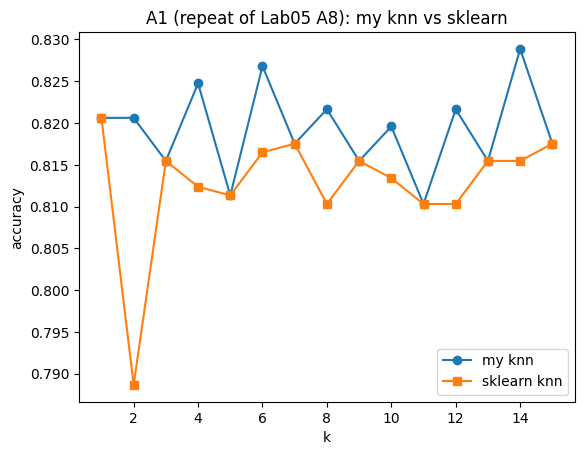

In [34]:
# plot 1: own kNN vs sklearn kNN, across k
fig1 = plt.figure()
plt.plot(list(k_range), my_acc, marker="o", label="my knn")
plt.plot(list(k_range), sk_acc, marker="s", label="sklearn knn")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.title("A1 (repeat of Lab05 A8): my knn vs sklearn")
plt.savefig("plot1_own_vs_sklearn.png")
plt.show()

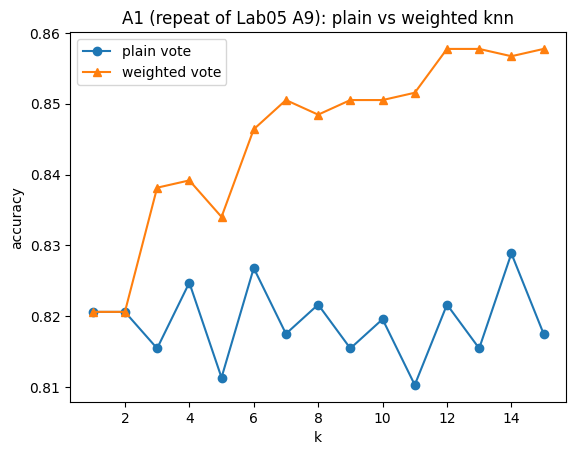

In [35]:
# plot 2: plain vote vs weighted vote, across k
fig2 = plt.figure()
plt.plot(list(k_range), my_acc, marker="o", label="plain vote")
plt.plot(list(k_range), weighted_acc, marker="^", label="weighted vote")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.title("A1 (repeat of Lab05 A9): plain vs weighted knn")
plt.savefig("plot2_plain_vs_weighted.png")
plt.show()

## A3: performance comparison - own kNN vs sklearn kNN vs GenAI kNN
accuracy, precision, recall, F1, and time averaged over 10 runs, at k=3

In [36]:
K = 3
N_RUNS = 10

def time_it(fn, n_runs=N_RUNS):
    times = []
    result = None
    for _ in range(n_runs):
        start = time.time()
        result = fn()
        times.append(time.time() - start)
    return result, np.mean(times)

# --- own kNN ---
own_model = fit(X_train, y_train)
own_preds, own_time = time_it(lambda: predict(own_model, X_test, K))

# --- sklearn kNN ---
sk_model = KNeighborsClassifier(n_neighbors=K)
sk_model.fit(X_train, y_train)
sk_preds, sk_time = time_it(lambda: sk_model.predict(X_test))

# --- GenAI kNN ---
genai_model = genai_knn_fit(X_train, y_train)
genai_preds, genai_time = time_it(lambda: genai_knn_predict(genai_model, X_test, K))

results = {
    "own kNN": (own_preds, own_time),
    "sklearn kNN": (sk_preds, sk_time),
    "GenAI kNN": (genai_preds, genai_time),
}

In [37]:
print(f"{'method':<15}{'accuracy':<10}{'precision':<11}{'recall':<9}{'f1':<9}{'avg time (s)'}")
table = []
for name, (preds, avg_time) in results.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="binary", zero_division=0)
    rec = recall_score(y_test, preds, average="binary", zero_division=0)
    f1 = f1_score(y_test, preds, average="binary", zero_division=0)
    table.append((name, acc, prec, rec, f1, avg_time))
    print(f"{name:<15}{acc:<10.3f}{prec:<11.3f}{rec:<9.3f}{f1:<9.3f}{avg_time:.6f}")

method         accuracy  precision  recall   f1       avg time (s)
own kNN        0.815     0.811      0.835    0.823    7.216958
sklearn kNN    0.815     0.811      0.835    0.823    0.004115
GenAI kNN      0.815     0.811      0.835    0.823    0.132126


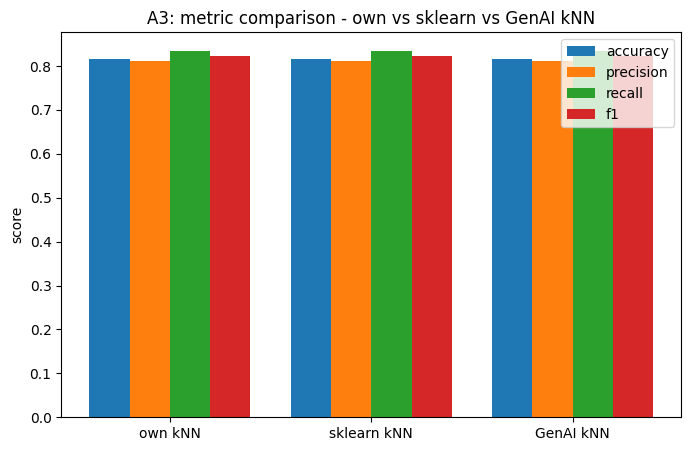

In [38]:
# plot 3: accuracy metrics comparison
names = [row[0] for row in table]
metrics_names = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(names))
width = 0.2

fig3 = plt.figure(figsize=(8, 5))
for i, m in enumerate(metrics_names):
    values = [row[1 + i] for row in table]
    plt.bar(x + i * width, values, width, label=m)
plt.xticks(x + width * 1.5, names)
plt.ylabel("score")
plt.title("A3: metric comparison - own vs sklearn vs GenAI kNN")
plt.legend()
plt.savefig("plot3_a3_metrics_comparison.png")
plt.show()

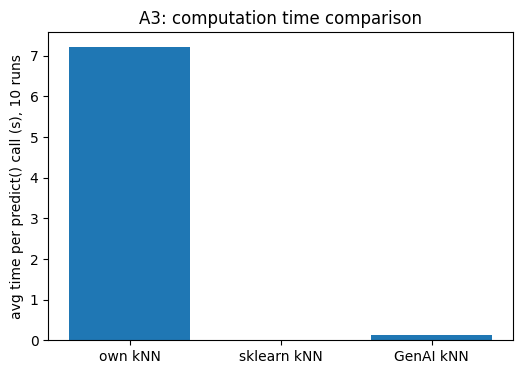

total figures generated in this notebook: 4
saved as: plot1_own_vs_sklearn.png, plot2_plain_vs_weighted.png,
          plot3_a3_metrics_comparison.png, plot4_a3_time_comparison.png


In [39]:
# plot 4: time comparison
times = [row[5] for row in table]
fig4 = plt.figure(figsize=(6, 4))
plt.bar(names, times)
plt.ylabel("avg time per predict() call (s), 10 runs")
plt.title("A3: computation time comparison")
plt.savefig("plot4_a3_time_comparison.png")
plt.show()

print("total figures generated in this notebook: 4")
print("saved as: plot1_own_vs_sklearn.png, plot2_plain_vs_weighted.png,")
print("          plot3_a3_metrics_comparison.png, plot4_a3_time_comparison.png")

## A2: unit tests (AI-generated) for modular functions - Lab05 + Lab06

In [40]:
import unittest

# --- unit tests, generated with AI assistance (Claude) ---
class TestLab05Functions(unittest.TestCase):
    def test_euclidean(self):
        self.assertAlmostEqual(euclidean(np.array([0,0]), np.array([3,4])), 5.0)

    def test_manhattan(self):
        self.assertEqual(manhattan(np.array([0,0]), np.array([3,4])), 7)

    def test_minkowski_p3(self):
        d = minkowski(np.array([0,0]), np.array([1,1]), p=3)
        self.assertAlmostEqual(d, (2) ** (1/3), places=4)

    def test_bubble_sort(self):
        pairs = [(3,0),(1,1),(2,2)]
        sorted_pairs = bubble_sort(pairs)
        self.assertEqual([p[0] for p in sorted_pairs], [1,2,3])

    def test_insertion_sort(self):
        pairs = [(3,0),(1,1),(2,2)]
        sorted_pairs = insertion_sort(pairs)
        self.assertEqual([p[0] for p in sorted_pairs], [1,2,3])

    def test_merge_sort(self):
        pairs = [(3,0),(1,1),(2,2)]
        sorted_pairs = merge_sort(pairs)
        self.assertEqual([p[0] for p in sorted_pairs], [1,2,3])

    def test_get_neighbors_tie_break(self):
        sorted_pairs = [(1.0,0),(1.0,1),(2.0,2),(2.0,4),(3.0,3)]
        neighbors = get_neighbors(sorted_pairs, 3)
        self.assertEqual(neighbors, [(1.0,0),(1.0,1),(2.0,2)])

    def test_majority_vote(self):
        neighbors = [(1.0,0),(1.0,1),(2.0,2)]
        y_train = np.array(["happy","sad","happy"])
        self.assertEqual(majority_vote(neighbors, y_train), "happy")

    def test_weighted_vote(self):
        neighbors = [(0.5,0),(0.6,1),(0.7,2),(50.0,3)]
        y_train = np.array(["sad","happy","happy","sad"])
        self.assertEqual(weighted_vote(neighbors, y_train), "happy")

    def test_encode_labels(self):
        encoded, mapping = encode_labels(["sad","happy","happy"])
        self.assertEqual(mapping, {"happy": 0, "sad": 1})
        self.assertListEqual(list(encoded), [1,0,0])

    def test_fill_missing_mean(self):
        X = np.array([[1.0, np.nan],[3.0, 4.0]])
        filled = fill_missing(X, method="mean")
        self.assertEqual(filled[0,1], 4.0)  # only non-nan value in that column

    def test_accuracy(self):
        self.assertEqual(accuracy([1,0,1],[1,0,0]), 2/3)


class TestLab06Functions(unittest.TestCase):
    def test_genai_knn_matches_own_knn(self):
        X_tr = np.array([[0,0],[1,0],[5,5],[6,5]])
        y_tr = np.array(["a","a","b","b"])
        model_own = fit(X_tr, y_tr)
        model_genai = genai_knn_fit(X_tr, y_tr)
        test_point = [[0.5, 0]]
        own_pred = predict(model_own, test_point, k=2)
        genai_pred = genai_knn_predict(model_genai, test_point, k=2)
        self.assertEqual(own_pred[0], genai_pred[0])

unittest.main(argv=["ignored", "-v"], exit=False)

test_accuracy (__main__.TestLab05Functions.test_accuracy) ... ok
test_bubble_sort (__main__.TestLab05Functions.test_bubble_sort) ... ok
test_encode_labels (__main__.TestLab05Functions.test_encode_labels) ... ok
test_euclidean (__main__.TestLab05Functions.test_euclidean) ... ok
test_fill_missing_mean (__main__.TestLab05Functions.test_fill_missing_mean) ... ok
test_get_neighbors_tie_break (__main__.TestLab05Functions.test_get_neighbors_tie_break) ... ok
test_insertion_sort (__main__.TestLab05Functions.test_insertion_sort) ... ok
test_majority_vote (__main__.TestLab05Functions.test_majority_vote) ... ok
test_manhattan (__main__.TestLab05Functions.test_manhattan) ... ok
test_merge_sort (__main__.TestLab05Functions.test_merge_sort) ... ok
test_minkowski_p3 (__main__.TestLab05Functions.test_minkowski_p3) ... ok
test_weighted_vote (__main__.TestLab05Functions.test_weighted_vote) ... ok
test_genai_knn_matches_own_knn (__main__.TestLab06Functions.test_genai_knn_matches_own_knn) ... ok

--------